## 1. Install & Imports

In [9]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:

train_df = pd.read_csv("data/train.csv")
val_df   = pd.read_csv("data/val.csv")
test_df  = pd.read_csv("data/test.csv")

In [12]:
FEATURES = [
    # area
    "area_encoded",

    # current week weather
    "avg_temperature_2m_mean",
    "avg_temperature_2m_max",
    "avg_precipitation_sum",
    "avg_relative_humidity_2m_mean",
    "temp_range",
    "heat_humidity_index",

    # seasonal cycle — sin/cos tell the model WHERE in the year we are
    # week_sin peaks at mid-year, week_cos peaks at start/end of year
    "week_sin",
    "week_cos",

    # case lag features
    "cases_lag1",
    "cases_lag2",
    "cases_lag3",
    "cases_roll_mean4",
    "cases_trend",

    # weather from the PREVIOUS week
    # mosquito breeding reacts to rain/heat with a delay of ~1 week
    "temp_lag1",
    "precip_lag1",
    "humidity_lag1",
]

X_train = train_df[FEATURES]
X_val   = val_df[FEATURES]
X_test  = test_df[FEATURES]

# train on log1p(cases) — compresses big spikes so the model learns better
y_train = train_df["cases_log1p"]
y_val   = val_df["cases_log1p"]

# keep raw counts aside for final evaluation
y_test_raw = test_df["cases"].values



In [13]:
# the grid: every combination of these values will be tested
param_grid = {
    "max_depth"        : [4, 6, 8],
    "learning_rate"    : [0.01, 0.05],   # keep these two
    "n_estimators"     : [500, 700,1000],
    "min_child_weight" : [3, 5, 7],      # add 7 — helps with noisy spike weeks
    "subsample"        : [0.7, 0.8],     # try 0.7 too
    "colsample_bytree" : [0.8],
}
# base model (no hyperparameters set — GridSearchCV fills those in)
base_model = xgb.XGBRegressor(
    eval_metric  = "rmse",
    random_state = 42,
    n_jobs       = -1,
)

grid_search = GridSearchCV(
    estimator  = base_model,
    param_grid = param_grid,
    scoring    = "neg_mean_absolute_error",  # maximise negative MAE = minimise MAE
    cv         = 3,                          # 3-fold cross validation
    verbose    = 1,                          # print progress
    n_jobs     = -1,
)

grid_search.fit(X_train.values, y_train.values)

print("\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:20s}: {value}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best parameters found:
  colsample_bytree    : 0.8
  learning_rate       : 0.01
  max_depth           : 6
  min_child_weight    : 3
  n_estimators        : 1000
  subsample           : 0.7


In [14]:
best_params = grid_search.best_params_

model = xgb.XGBRegressor(
    **best_params,                  # unpack the best settings found above
    early_stopping_rounds = 30,     # stop if val score doesn't improve for 30 rounds 
    eval_metric           = "rmse",
    random_state          = 42,
    n_jobs                = -1,
)

model.fit(
    X_train.values, y_train.values,
    eval_set=[(X_val.values, y_val.values)],
    verbose=100
)

print(f"\nStopped at tree #{model.best_iteration}")

[0]	validation_0-rmse:0.79134
[100]	validation_0-rmse:0.54540
[200]	validation_0-rmse:0.50503
[300]	validation_0-rmse:0.50014
[400]	validation_0-rmse:0.49962
[433]	validation_0-rmse:0.49962

Stopped at tree #403


In [15]:
# convert log predictions back to real case counts
y_pred = np.expm1(model.predict(X_test.values)).clip(0)

mae  = mean_absolute_error(y_test_raw, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
r2   = r2_score(y_test_raw, y_pred)

print(f"MAE  : {mae:.4f} cases   (on average, prediction is off by this many cases)")
print(f"RMSE : {rmse:.4f} cases   (penalises big misses more than MAE)")
print(f"R2   : {r2:.4f}          (1.0 = perfect, 0.0 = no better than guessing the mean)")

MAE  : 1.5818 cases   (on average, prediction is off by this many cases)
RMSE : 3.0290 cases   (penalises big misses more than MAE)
R2   : 0.5602          (1.0 = perfect, 0.0 = no better than guessing the mean)


In [16]:
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/dengue_model.pkl")

print("Saved to models/dengue_model.pkl")
print(f"\nBest params : {best_params}")
print(f"MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")


Saved to models/dengue_model.pkl

Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 1000, 'subsample': 0.7}
MAE=1.5818  RMSE=3.0290  R2=0.5602


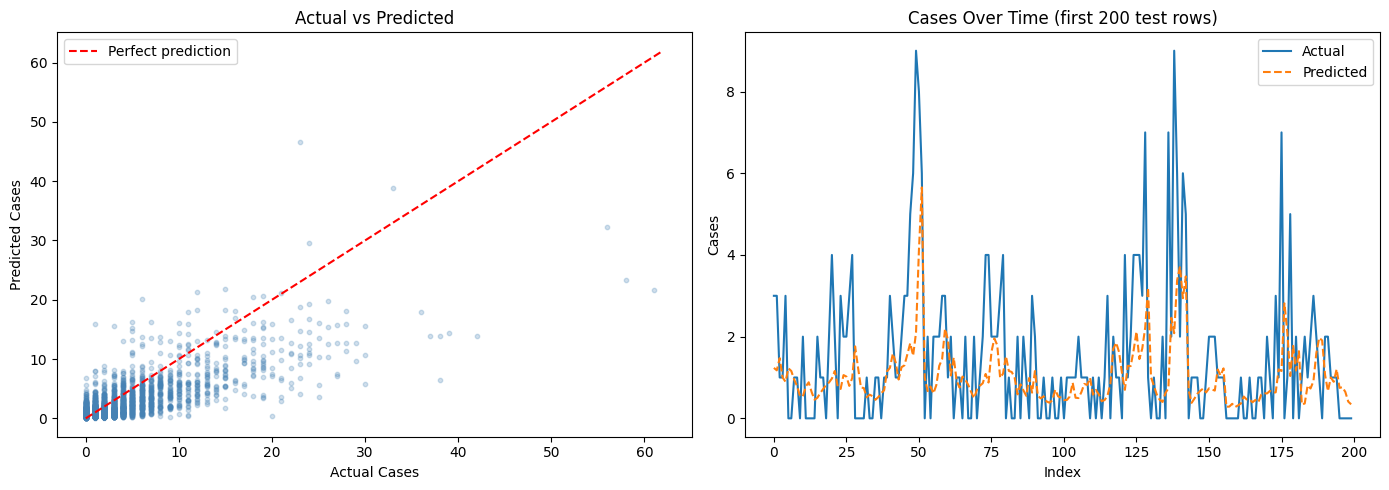

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# actual vs predicted scatter
axes[0].scatter(y_test_raw, y_pred, alpha=0.25, s=10, color="steelblue")
lim = max(y_test_raw.max(), y_pred.max()) + 1
axes[0].plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect prediction")
axes[0].set(title="Actual vs Predicted", xlabel="Actual Cases", ylabel="Predicted Cases")
axes[0].legend()

# time series preview
n = min(200, len(y_test_raw))
axes[1].plot(y_test_raw[:n], label="Actual",    lw=1.5)
axes[1].plot(y_pred[:n],     label="Predicted", lw=1.5, linestyle="--")
axes[1].set(title="Cases Over Time (first 200 test rows)", xlabel="Index", ylabel="Cases")
axes[1].legend()

plt.tight_layout()
plt.show()


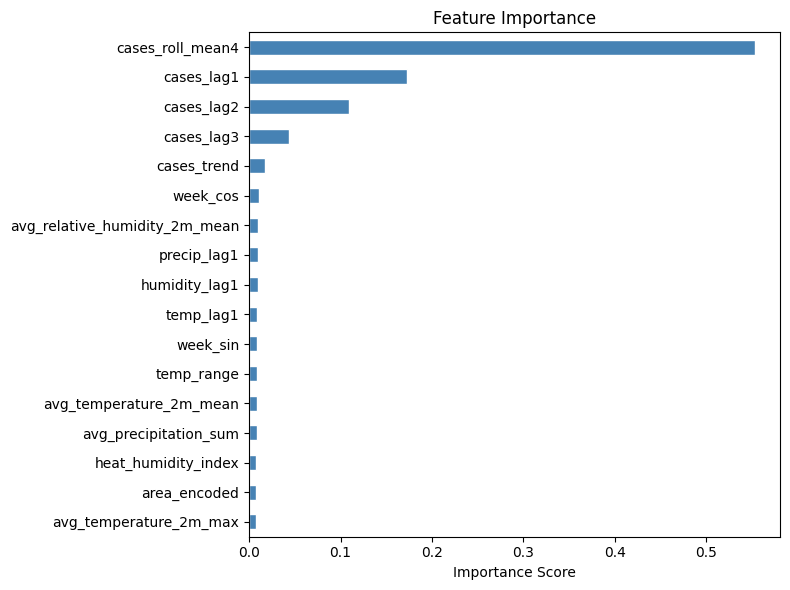


Top 5 most important features:
cases_trend         0.017556
cases_lag3          0.043387
cases_lag2          0.109048
cases_lag1          0.172716
cases_roll_mean4    0.552903


In [18]:
# feature importance — which features the model relied on most
importance = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh", color="steelblue", edgecolor="white")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance.tail(5).to_string())